In [1]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os

lag = 20

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
data = dataloader(path=path, lag=lag)

2024-04-11 01:14:39.117 | INFO     | utils.DataPreprocessing:load_csv:129 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-04-11 01:14:39.119 | INFO     | utils.DataPreprocessing:load_csv:131 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park


2024-04-11 01:14:39.310 | INFO     | utils.DataPreprocessing:feature_engineering:283 - shape: (8_523, 16)
┌───────────┬────────────┬───────────┬──────┬───┬────────────┬────────────┬───────────┬─────────┐
│ AVG_TEMP  ┆ date       ┆ GSR       ┆ SUN  ┆ … ┆ dayofmonth ┆ weekofyear ┆ dayofyear ┆ quarter │
│ ---       ┆ ---        ┆ ---       ┆ ---  ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---     │
│ f32       ┆ date       ┆ f32       ┆ f32  ┆   ┆ i8         ┆ i8         ┆ i16       ┆ i8      │
╞═══════════╪════════════╪═══════════╪══════╪═══╪════════════╪════════════╪═══════════╪═════════╡
│ 29.200001 ┆ 1999-08-01 ┆ 25.1      ┆ 11.6 ┆ … ┆ 1          ┆ 30         ┆ 213       ┆ 3       │
│ 29.1      ┆ 1999-08-02 ┆ 15.13     ┆ 7.0  ┆ … ┆ 2          ┆ 31         ┆ 214       ┆ 3       │
│ 29.0      ┆ 1999-08-03 ┆ 11.85     ┆ 2.4  ┆ … ┆ 3          ┆ 31         ┆ 215       ┆ 3       │
│ 27.5      ┆ 1999-08-04 ┆ 10.67     ┆ 2.3  ┆ … ┆ 4          ┆ 31         ┆ 216       ┆ 3       │
│ 27.9      

In [41]:
print(data.X_train[0].columns)

['AVG_TEMP', 'GSR', 'SUN', 'RH', 'UV', 'RF', 'WSPD', 'weather', 'dayofweek', 'Month', 'year', 'dayofmonth', 'weekofyear', 'dayofyear', 'quarter']


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf

n_past = lag
n_future = 1
n_features = 15
output_features = 8

2024-04-11 01:14:40.577169: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-11 01:14:41.789336: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
import polars as pl
X = data.X_train
X_train = np.array([])
for df in X:
    df = pl.DataFrame(df)
    df = df.to_numpy()
    df = df.reshape((1, df.shape[0], df.shape[1]))
    # print(df.shape)
    if X_train.shape[0] == 0:
        X_train = df
    else:
        X_train = np.vstack((X_train, df))

print(X_train.shape)


(6798, 20, 15)


In [4]:
y = data.y_train   
y_train = np.array([])
for df in y:
    df = pl.DataFrame(df)
    df = df.to_numpy()
    df = df.reshape((1, df.shape[0], df.shape[1]))
    # print(df.shape)
    if y_train.shape[0] == 0:
        y_train = df
    else:
        y_train = np.vstack((y_train, df))

print(y_train.shape)

(6798, 1, 8)


In [5]:
X = data.X_test
X_test = np.array([])
for df in X:
    df = pl.DataFrame(df)
    df = df.to_numpy()
    df = df.reshape((1, df.shape[0], df.shape[1]))
    # print(df.shape)
    if X_test.shape[0] == 0:
        X_test = df
    else:
        X_test = np.vstack((X_test, df))
        
print(X_test.shape)

(1685, 20, 15)


In [6]:
y = data.y_test
y_test = np.array([])
for df in y:
    df = pl.DataFrame(df)
    df = df.to_numpy()
    df = df.reshape((1, df.shape[0], df.shape[1]))
    # print(df.shape)
    if y_test.shape[0] == 0:
        y_test = df
    else:
        y_test = np.vstack((y_test, df))
        
print(y_test.shape)

(1685, 1, 8)


In [18]:
# E1D1
# n_features ==> no of features at each timestep in the data.
#
import keras

hidden_size = 50

encoder_inputs = keras.layers.Input(shape=(n_past, n_features))
encoder_l1 = keras.layers.LSTM(hidden_size, return_state=True)
encoder_outputs1 = encoder_l1(encoder_inputs)

encoder_states1 = encoder_outputs1[1:]

#
decoder_inputs = keras.layers.RepeatVector(n_future)(encoder_outputs1[0])

#
decoder_l1 = keras.layers.LSTM(hidden_size, return_sequences=True)(
    decoder_inputs, initial_state=encoder_states1
)
decoder_outputs1 = keras.layers.TimeDistributed(keras.layers.Dense(output_features))(
    decoder_l1
)

#
model_e1d1 = keras.models.Model(encoder_inputs, decoder_outputs1)

#
model_e1d1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 50),      │     13,200 │ input_layer_1[0]… │
│                     │ (None, 50),       │            │                   │
│                     │ (None, 50)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 1, 50)     │          0 │ lstm_2[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 1, 50)     │     20,200 │ repeat_vector_1[… │
│                     │                   │            │ lstm_2[0][1],     │
│                     │                   │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 1, 8)      │        408 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,808 (132.06 KB)

 Trainable params: 33,808 (132.06 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# reduce_lr = keras.callbacks.LearningRateScheduler(lambda x: 1e-3 * 0.90**x)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, mode='auto')
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, mode='auto')
model_e1d1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss=keras.losses.Huber())

In [34]:
# Building the RNN
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

regressor = Sequential()

# Addinf the first LSTM layer and some Dropout regularisation
regressor.add(LSTM(units=hidden_size, return_sequences=True, input_shape=(n_past, n_features)))
regressor.add(Dropout(0.5))

regressor.add(LSTM(units=hidden_size, return_sequences=True))
regressor.add(Dropout(0.5))

regressor.add(LSTM(units=hidden_size, return_sequences=True))
regressor.add(Dropout(0.5))

regressor.add(LSTM(units=hidden_size))
regressor.add(Dropout(0.5))

# Output layer
regressor.add(Dense(units=output_features))
regressor.summary()

regressor.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mean_squared_error",
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 20, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 20, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 20, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,208 (289.88 KB)

 Trainable params: 74,208 (289.88 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_e1d1 = model_e1d1.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    batch_size=32,
    verbose=1,
    callbacks=[reduce_lr, early_stopping],
)

Epoch 1/500


213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 10.4163 - val_loss: 3.4862 - learning_rate: 0.0100
Epoch 2/500
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.5254 - val_loss: 3.4672 - learning_rate: 0.0100
Epoch 3/500
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.5481 - val_loss: 3.4288 - learning_rate: 0.0100
Epoch 4/500
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.5466 - val_loss: 3.4714 - learning_rate: 0.0100
Epoch 5/500
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.4987 - val_loss: 3.4676 - learning_rate: 0.0100
Epoch 6/500
210/213 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.5836
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.5830 - val_loss: 3.5184 - learning_rate: 0.0100
Epoch 7/500
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.5529 - val_loss: 3.4541 - learning_rate: 0.0050
Epoch 8/500
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.5530 - val_loss: 3.4352 - learn

In [35]:
history_reg = regressor.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    batch_size=32,
    verbose=1,
    callbacks=[reduce_lr, early_stopping],
)

Epoch 1/100


213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - loss: 419.6257 - val_loss: 62.4804 - learning_rate: 0.0100
Epoch 2/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 76.3551 - val_loss: 58.9231 - learning_rate: 0.0100
Epoch 3/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 73.9259 - val_loss: 59.0455 - learning_rate: 0.0100
Epoch 4/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 74.4701 - val_loss: 58.8351 - learning_rate: 0.0100
Epoch 5/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 75.0546 - val_loss: 59.9851 - learning_rate: 0.0100
Epoch 6/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 73.3680 - val_loss: 58.7571 - learning_rate: 0.0100
Epoch 7/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 73.6035 - val_loss: 59.3100 - learning_rate: 0.0100
Epoch 8/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 75.6296 - val_loss: 58.4401 - learning_rate: 0.0100
Epoch 9/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 71.5610 - val_loss: 58.8019 

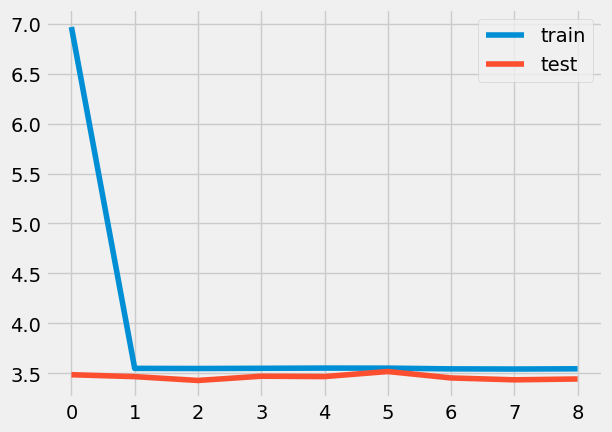

In [36]:
# plot the test result
plt.plot(history_e1d1.history['loss'], label='train')
plt.plot(history_e1d1.history['val_loss'], label='test')
plt.legend()
plt.show()

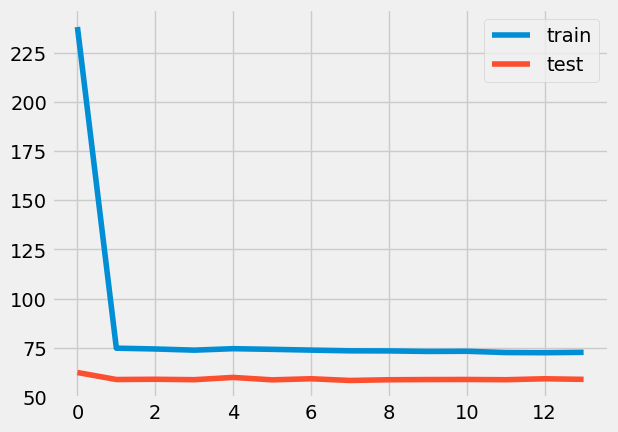

In [37]:
# plot the test result
plt.plot(history_reg.history["loss"], label="train")
plt.plot(history_reg.history["val_loss"], label="test")
plt.legend()
plt.show()

In [38]:
pred = regressor.predict(X_test)
# plot the prediction of the test data
print(pred)
# only grab the first features, turns from (4,1,8) to (4,1)
pred = pred[:, :, 0]
test = y_test[:, :, 0]

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
[[22.672878  12.7978735  4.9937925 ...  5.564943   8.797966   0.8028258]
 [22.672878  12.7978735  4.9937925 ...  5.564943   8.797966   0.8028258]
 [22.672878  12.7978735  4.9937925 ...  5.564943   8.797966   0.8028258]
 ...
 [22.672878  12.7978735  4.9937925 ...  5.564943   8.797966   0.8028258]
 [22.672878  12.7978735  4.9937925 ...  5.564943   8.797966   0.8028258]
 [22.672878  12.7978735  4.9937925 ...  5.564943   8.797966   0.8028258]]


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [24]:
print(X_test.shape)

(1685, 20, 15)


(1685, 1)
(1685, 1)


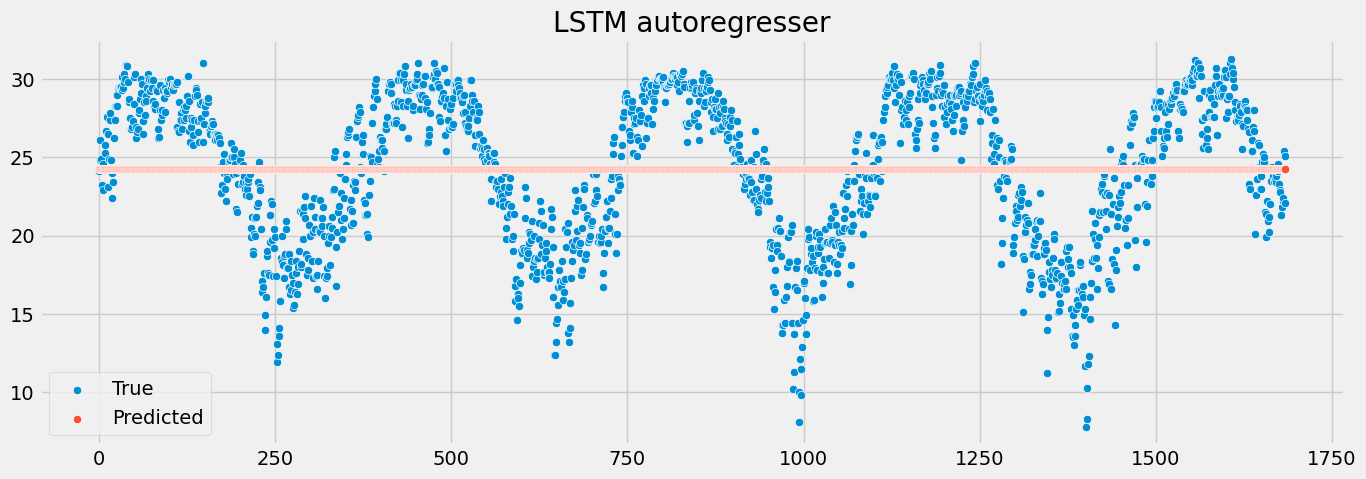

In [25]:
print(pred.shape)
print(test.shape)

# plot the prediction of the test data
import seaborn as sns
x_values = np.arange(pred.shape[0])
fig, ax = plt.subplots(
    figsize=(15, 5),
)

plt.title('LSTM autoregresser')

sns.scatterplot(x=x_values, y=test[:, 0], ax=ax, label='True')
sns.scatterplot(x=x_values, y=pred[:, 0], ax=ax, label='Predicted')
plt.show()

In [26]:
pred = model_e1d1.predict(X_train)
# plot the prediction of the test data
print(pred)
# only grab the first features, turns from (4,1,8) to (4,1)
pred = pred[:, :, 0]
test = y_train[:, :, 0]

  1/213 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[[[24.22113    13.936025    4.8609724  ...  0.22163849  8.94244
    0.8937392 ]]

 [[24.22113    13.936025    4.8609724  ...  0.22163849  8.94244
    0.8937392 ]]

 [[24.22113    13.936025    4.8609724  ...  0.22163849  8.94244
    0.8937392 ]]

 ...

 [[24.22113    13.936025    4.8609724  ...  0.22163849  8.94244
    0.8937392 ]]

 [[24.22113    13.936024    4.8609724  ...  0.22163843  8.942439
    0.8937393 ]]

 [[24.22113    13.936024    4.8609724  ...  0.22163843  8.942439
    0.8937393 ]]]


(6798, 1)
(6798, 1)


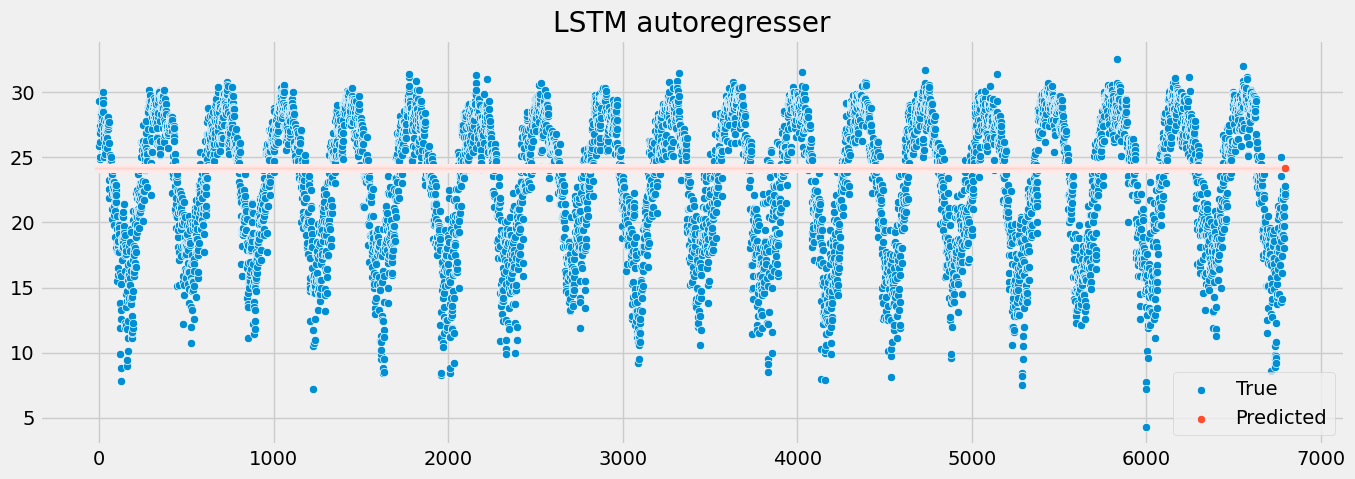

In [27]:
print(pred.shape)
print(test.shape)

# plot the prediction of the test data
import seaborn as sns

x_values = np.arange(pred.shape[0])
fig, ax = plt.subplots(
    figsize=(15, 5),
)

plt.title("LSTM autoregresser")

sns.scatterplot(x=x_values, y=test[:, 0], ax=ax, label="True")
sns.scatterplot(x=x_values, y=pred[:, 0], ax=ax, label="Predicted")
plt.show()